# 🛍️ Marketing Campaign Prediction Project
### Nykaa · Purplle · Tira — Revenue Regression & Profit/Loss Classification

This notebook walks through the **entire pipeline** step by step, ready to run top-to-bottom in Google Colab:

1. Setup & folder structure
2. Generate the raw dataset
3. Data preprocessing / cleaning
4. Feature engineering
5. Exploratory Data Analysis (EDA)
6. Regression modeling — predict **Revenue**
7. Classification modeling — predict **Profit_Flag** (profit vs loss)
8. Combined model evaluation report
9. Download all outputs (data, models, figures, reports) as a ZIP

> Just run the cells in order (**Runtime → Run all**). Each step saves its output to disk so later steps can read from previous ones, exactly like the original project structure.


## Step 0 — Setup: install packages & create folder structure

In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tabulate joblib

import os

# Recreate the project folder structure inside Colab's /content
BASE_DIR = "/content/Marketing_Campaign_Prediction_Project"
DIRS = ["data", "models", "reports", "reports/figures", "src", "app", "docs"]

for d in DIRS:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

os.chdir(BASE_DIR)
print("Working directory:", os.getcwd())
print("Folders created:", os.listdir(BASE_DIR))


Working directory: c:\content\Marketing_Campaign_Prediction_Project
Folders created: ['app', 'data', 'docs', 'models', 'reports', 'src']


## Step 1 — Generate the raw dataset

No source dataset was provided with the project, so this step **synthesizes a realistic raw dataset** matching the exact schema described in the project brief for Nykaa, Purplle, and Tira — including intentional data-quality issues:
- Missing values across several columns
- Duplicate rows (simulated double-logging)
- Multi-channel strings in `Channel_Used` (e.g. `"Instagram, Email"`)
- Corrupted / inconsistent `ROI` values

**Output:** `data/marketing_campaign_raw.csv`


In [3]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

N = 6000  # number of campaign records

brands = ["Nykaa", "Purplle", "Tira"]
campaign_types = ["Awareness", "Conversion", "Promotion", "Retention", "Product Launch"]
target_audiences = ["Gen Z", "Millennials", "Working Professionals", "Students", "Premium Shoppers"]
channels_pool = ["Instagram", "Facebook", "Google Ads", "YouTube", "Email", "Influencer", "SMS"]
languages = ["English", "Hindi", "Tamil", "Telugu", "Kannada", "Bengali"]
customer_segments = ["New", "Returning", "Premium"]

def random_channels():
    """Simulate the messy multi-channel column, e.g. 'Instagram, Email' """
    k = np.random.choice([1, 2, 3], p=[0.5, 0.35, 0.15])
    chosen = np.random.choice(channels_pool, size=k, replace=False)
    return ", ".join(chosen)

start_date = datetime(2023, 1, 1)
rows = []
for i in range(N):
    brand = np.random.choice(brands, p=[0.45, 0.35, 0.20])
    campaign_type = np.random.choice(campaign_types)
    audience = np.random.choice(target_audiences)
    duration = int(np.random.randint(3, 60))
    channels = random_channels()
    impressions = int(np.random.gamma(shape=2.0, scale=25000))
    ctr = np.clip(np.random.normal(0.03, 0.015), 0.001, 0.15)
    clicks = int(impressions * ctr)
    lead_rate = np.clip(np.random.normal(0.12, 0.05), 0.01, 0.5)
    leads = int(clicks * lead_rate)
    conv_rate = np.clip(np.random.normal(0.20, 0.08), 0.01, 0.6)
    conversions = int(leads * conv_rate)
    avg_order_value = np.random.uniform(400, 3500)
    revenue = round(conversions * avg_order_value * np.random.uniform(0.85, 1.2), 2)
    acquisition_cost = round(impressions * np.random.uniform(0.15, 0.6) + clicks * np.random.uniform(1, 4), 2)
    acquisition_cost = max(acquisition_cost, 500)
    roi = round((revenue - acquisition_cost) / acquisition_cost, 3) if acquisition_cost > 0 else np.nan
    language = np.random.choice(languages, p=[0.5, 0.2, 0.1, 0.08, 0.07, 0.05])
    engagement_score = round(np.clip(np.random.normal(6.5, 1.8), 0, 10), 2)
    segment = np.random.choice(customer_segments, p=[0.4, 0.4, 0.2])
    date = start_date + timedelta(days=int(np.random.randint(0, 700)))

    rows.append([
        f"CMP{100000+i}", brand, campaign_type, audience, duration, channels,
        impressions, clicks, leads, conversions, revenue, acquisition_cost, roi,
        language, engagement_score, segment, date.strftime("%Y-%m-%d")
    ])

cols = ["Campaign_ID", "Brand", "Campaign_Type", "Target_Audience", "Duration",
        "Channel_Used", "Impressions", "Clicks", "Leads", "Conversions", "Revenue",
        "Acquisition_Cost", "ROI", "Language", "Engagement_Score", "Customer_Segment", "Date"]

df = pd.DataFrame(rows, columns=cols)

# ---- Inject realistic data-quality issues ----

# 1. Missing values across several columns
for col, frac in [("Revenue", 0.03), ("Acquisition_Cost", 0.02), ("ROI", 0.04),
                   ("Engagement_Score", 0.05), ("Channel_Used", 0.015), ("Leads", 0.02)]:
    idx = df.sample(frac=frac, random_state=hash(col) % 1000).index
    df.loc[idx, col] = np.nan

# 2. Duplicate rows (simulate accidental double-logging of campaigns)
dupes = df.sample(frac=0.02, random_state=7)
df = pd.concat([df, dupes], ignore_index=True)

# 3. Inconsistent / corrupted ROI values (wrong sign, extreme outliers)
corrupt_idx = df.sample(frac=0.01, random_state=11).index
df.loc[corrupt_idx, "ROI"] = df.loc[corrupt_idx, "ROI"] * -100  # nonsensical spikes

# 4. Shuffle rows so duplicates aren't all at the bottom
df = df.sample(frac=1.0, random_state=99).reset_index(drop=True)

out_path = "data/marketing_campaign_raw.csv"
df.to_csv(out_path, index=False)
print(f"Generated raw dataset: {out_path}")
print(f"Shape: {df.shape}")
print(df.isna().sum())
df.head()


Generated raw dataset: data/marketing_campaign_raw.csv
Shape: (6120, 17)
Campaign_ID           0
Brand                 0
Campaign_Type         0
Target_Audience       0
Duration              0
Channel_Used         93
Impressions           0
Clicks                0
Leads               123
Conversions           0
Revenue             183
Acquisition_Cost    123
ROI                 246
Language              0
Engagement_Score    303
Customer_Segment      0
Date                  0
dtype: int64


,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,CMP103428,Nykaa,Conversion,Gen Z,33,Email,32548,1363,252.0,24,61269.01,22219.67,1.757,Telugu,7.34,Premium,2024-10-31
1,CMP105886,Nykaa,Product Launch,Premium Shoppers,4,Influencer,32373,530,81.0,14,7217.53,19067.71,-0.621,English,5.08,Premium,2023-07-11
2,CMP105925,Nykaa,Conversion,Premium Shoppers,50,"SMS, YouTube",10162,406,52.0,12,16641.59,5208.28,2.195,Bengali,7.14,Returning,2023-09-17
3,CMP105073,Purplle,Awareness,Gen Z,50,"Influencer, Facebook, SMS",136330,3353,282.0,71,47284.60,84274.62,-0.439,Bengali,6.55,Returning,2023-03-01
4,CMP102691,Purplle,Awareness,Students,41,"SMS, Email, Facebook",40136,801,40.0,11,9759.69,18147.25,-0.462,Bengali,8.96,New,2023-11-17


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Duration,6120.0,30.879575,16.398166,3.0,17.00000,31.00,45.0000,59.00
Impressions,6120.0,49496.285621,35525.072924,89.0,23499.25000,41169.00,67171.5000,321156.00
Clicks,6120.0,1515.751634,1415.102436,1.0,524.75000,1118.00,2065.2500,12743.00
Leads,5997.0,179.546106,196.846104,0.0,49.00000,118.00,237.0000,2094.00
Conversions,6120.0,35.634314,44.246674,0.0,7.75000,21.00,47.0000,433.00
Revenue,5937.0,71802.765550,104588.810487,0.0,11667.42000,35683.34,87433.6100,1052017.69
Acquisition_Cost,5997.0,22177.188774,17967.715472,500.0,9320.38000,17331.39,29840.3000,158264.88
ROI,5874.0,0.419264,38.174033,-1304.1,-0.14775,1.17,3.6005,100.00
Engagement_Score,5817.0,6.526180,1.748696,0.0,5.32000,6.54,7.7800,10.00


## Step 2 — Data preprocessing

Loads the raw CSV, inspects it, then cleans it:
1. Load & inspect structure / dtypes / missing values / duplicates
2. Remove duplicate rows
3. Handle missing values (median for numeric columns, `"Unknown"` for categorical)
4. **Recalculate ROI** from `Revenue` and `Acquisition_Cost` to fix missing/corrupted values
5. Fix data types (`Date` → datetime, integer columns rounded to `int`)

**Input:** `data/marketing_campaign_raw.csv` → **Output:** `data/marketing_campaign_clean.csv`


In [5]:
import pandas as pd
import numpy as np

RAW_PATH = "data/marketing_campaign_raw.csv"
CLEAN_PATH = "data/marketing_campaign_clean.csv"

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"Loaded raw data: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

def inspect(df: pd.DataFrame):
    print("\n--- Data types ---")
    print(df.dtypes)
    print("\n--- Missing values ---")
    print(df.isna().sum())
    print(f"\n--- Duplicate rows: {df.duplicated().sum()} ---")

def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates(subset=[c for c in df.columns if c != "Campaign_ID"], keep="first")
    df = df.drop_duplicates(subset="Campaign_ID", keep="first")
    print(f"Removed {before - len(df)} duplicate rows")
    return df.reset_index(drop=True)

def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = ["Impressions", "Clicks", "Leads", "Conversions", "Revenue",
                     "Acquisition_Cost", "Engagement_Score"]
    for col in numeric_cols:
        if df[col].isna().any():
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

    # Categorical: fill with "Unknown"
    if df["Channel_Used"].isna().any():
        df["Channel_Used"] = df["Channel_Used"].fillna("Unknown")

    return df

def validate_and_fix_roi(df: pd.DataFrame) -> pd.DataFrame:
    """ROI should equal (Revenue - Acquisition_Cost) / Acquisition_Cost.
    Recompute it from source columns to fix missing/corrupted entries,
    which also guarantees consistency for downstream feature engineering."""
    df["Acquisition_Cost"] = df["Acquisition_Cost"].replace(0, np.nan)
    df["Acquisition_Cost"] = df["Acquisition_Cost"].fillna(df["Acquisition_Cost"].median())
    df["ROI"] = (df["Revenue"] - df["Acquisition_Cost"]) / df["Acquisition_Cost"]
    df["ROI"] = df["ROI"].round(3)
    return df

def fix_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df["Date"] = pd.to_datetime(df["Date"])
    int_cols = ["Duration", "Impressions", "Clicks", "Leads", "Conversions"]
    for col in int_cols:
        df[col] = df[col].round(0).astype(int)
    return df

# ---- Run the pipeline ----
df = load_data(RAW_PATH)
inspect(df)
df = remove_duplicates(df)
df = handle_missing_values(df)
df = validate_and_fix_roi(df)
df = fix_dtypes(df)

print("\n--- Post-cleaning missing values ---")
print(df.isna().sum().sum(), "total missing values remaining")

df.to_csv(CLEAN_PATH, index=False)
print(f"\nSaved cleaned dataset to {CLEAN_PATH} -> shape {df.shape}")
df.head()


Loaded raw data: 6120 rows, 17 columns

--- Data types ---
Campaign_ID             str
Brand                   str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Impressions           int64
Clicks                int64
Leads               float64
Conversions           int64
Revenue             float64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
Date                    str
dtype: object

--- Missing values ---
Campaign_ID           0
Brand                 0
Campaign_Type         0
Target_Audience       0
Duration              0
Channel_Used         93
Impressions           0
Clicks                0
Leads               123
Conversions           0
Revenue             183
Acquisition_Cost    123
ROI                 246
Language              0
Engagement_Score    303
Customer_Segment      0
Date                  0
dtype: int64

--- D

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,CMP103428,Nykaa,Conversion,Gen Z,33,Email,32548,1363,252,24,61269.01,22219.67,1.757,Telugu,7.34,Premium,2024-10-31
1,CMP105886,Nykaa,Product Launch,Premium Shoppers,4,Influencer,32373,530,81,14,7217.53,19067.71,-0.621,English,5.08,Premium,2023-07-11
2,CMP105925,Nykaa,Conversion,Premium Shoppers,50,"SMS, YouTube",10162,406,52,12,16641.59,5208.28,2.195,Bengali,7.14,Returning,2023-09-17
3,CMP105073,Purplle,Awareness,Gen Z,50,"Influencer, Facebook, SMS",136330,3353,282,71,47284.60,84274.62,-0.439,Bengali,6.55,Returning,2023-03-01
4,CMP102691,Purplle,Awareness,Students,41,"SMS, Email, Facebook",40136,801,40,11,9759.69,18147.25,-0.462,Bengali,8.96,New,2023-11-17


## Step 3 — Feature engineering

Builds model-ready features from the cleaned dataset:
1. **Multi-label encoding** of `Channel_Used` (one binary column per channel, e.g. `Channel_Instagram`, `Channel_Email`)
2. **`Profit_Flag`** target — `1` if `ROI > 0` (profit), else `0` (loss)
3. **One-hot encoding** of categoricals: `Brand`, `Campaign_Type`, `Target_Audience`, `Language`, `Customer_Segment`
4. **Date-derived features**: `Campaign_Month`, `Campaign_DayOfWeek`

**Input:** `data/marketing_campaign_clean.csv` → **Output:** `data/marketing_campaign_features.csv`


In [6]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

CLEAN_PATH = "data/marketing_campaign_clean.csv"
FEATURES_PATH = "data/marketing_campaign_features.csv"

def multi_label_encode_channels(df: pd.DataFrame) -> pd.DataFrame:
    """Channel_Used contains comma-separated strings, e.g. 'Instagram, Email'.
    We split and binarize into one column per channel: Channel_Instagram, Channel_Email, etc."""
    channel_lists = df["Channel_Used"].apply(
        lambda x: [c.strip() for c in str(x).split(",")] if x != "Unknown" else []
    )
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(channel_lists)
    channel_df = pd.DataFrame(encoded, columns=[f"Channel_{c}" for c in mlb.classes_], index=df.index)
    df = pd.concat([df, channel_df], axis=1)
    return df

def create_profit_flag(df: pd.DataFrame) -> pd.DataFrame:
    """Profit_Flag = 1 if ROI > 0 (campaign was profitable), else 0."""
    df["Profit_Flag"] = (df["ROI"] > 0).astype(int)
    return df

def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Campaign_Month"] = df["Date"].dt.month
    df["Campaign_DayOfWeek"] = df["Date"].dt.dayofweek
    return df

def one_hot_encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    cat_cols = ["Brand", "Campaign_Type", "Target_Audience", "Language", "Customer_Segment"]
    df = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols, drop_first=False)
    return df

# ---- Run the pipeline ----
df = pd.read_csv(CLEAN_PATH)

df = multi_label_encode_channels(df)
df = create_profit_flag(df)
df = add_date_features(df)
df = one_hot_encode_categoricals(df)

# Drop raw text columns no longer needed for modeling
df = df.drop(columns=["Channel_Used", "Date", "Campaign_ID"])

print("Feature-engineered dataset shape:", df.shape)
print("\nProfit_Flag distribution:")
print(df["Profit_Flag"].value_counts(normalize=True).round(3))

df.to_csv(FEATURES_PATH, index=False)
print(f"\nSaved feature-engineered dataset to {FEATURES_PATH}")
df.head()


Feature-engineered dataset shape: (6000, 41)

Profit_Flag distribution:
Profit_Flag
1    0.724
0    0.276
Name: proportion, dtype: float64

Saved feature-engineered dataset to data/marketing_campaign_features.csv


,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Channel_Email,...,Target_Audience_Working Professionals,Language_Bengali,Language_English,Language_Hindi,Language_Kannada,Language_Tamil,Language_Telugu,Customer_Segment_New,Customer_Segment_Premium,Customer_Segment_Returning
0,33,32548,1363,252,24,61269.01,22219.67,1.757,7.34,1,...,False,False,False,False,False,False,True,False,True,False
1,4,32373,530,81,14,7217.53,19067.71,-0.621,5.08,0,...,False,False,True,False,False,False,False,False,True,False
2,50,10162,406,52,12,16641.59,5208.28,2.195,7.14,0,...,False,True,False,False,False,False,False,False,False,True
3,50,136330,3353,282,71,47284.60,84274.62,-0.439,6.55,0,...,False,True,False,False,False,False,False,False,False,True
4,41,40136,801,40,11,9759.69,18147.25,-0.462,8.96,1,...,False,True,False,False,False,False,False,True,False,False


## Step 4 — Exploratory Data Analysis (EDA)

Generates charts (saved as PNGs **and** displayed inline) plus a written insights report.

**Input:** `data/marketing_campaign_clean.csv`
**Output:** `reports/figures/*.png`, `reports/EDA_report.md`


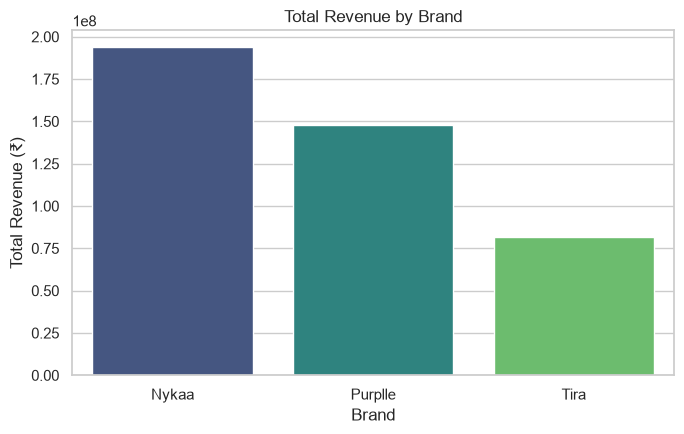

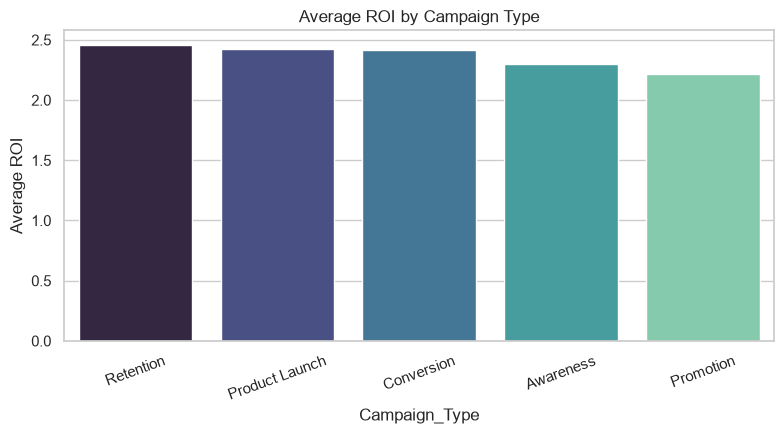

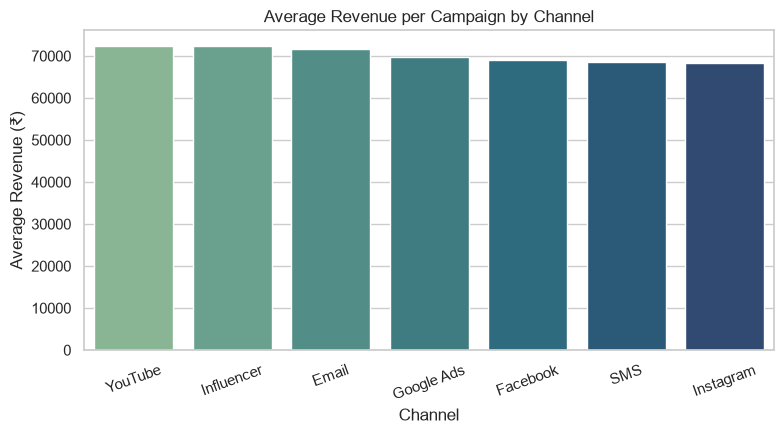

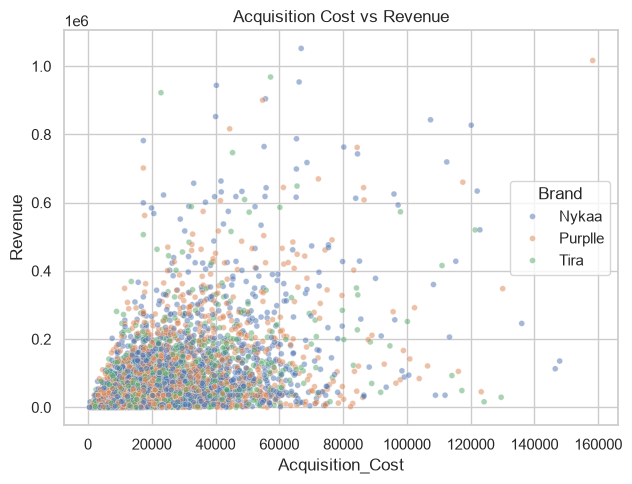

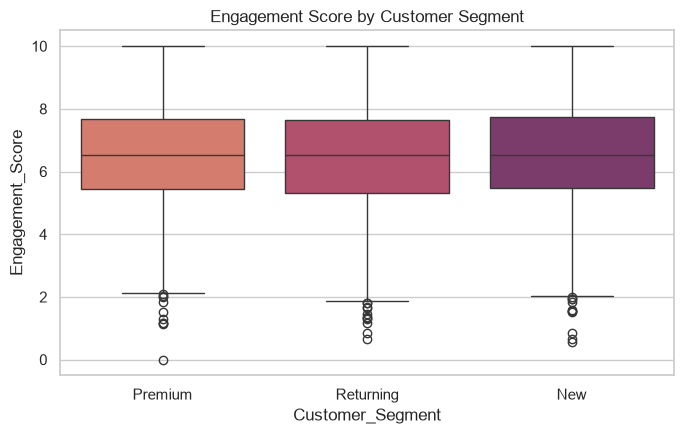

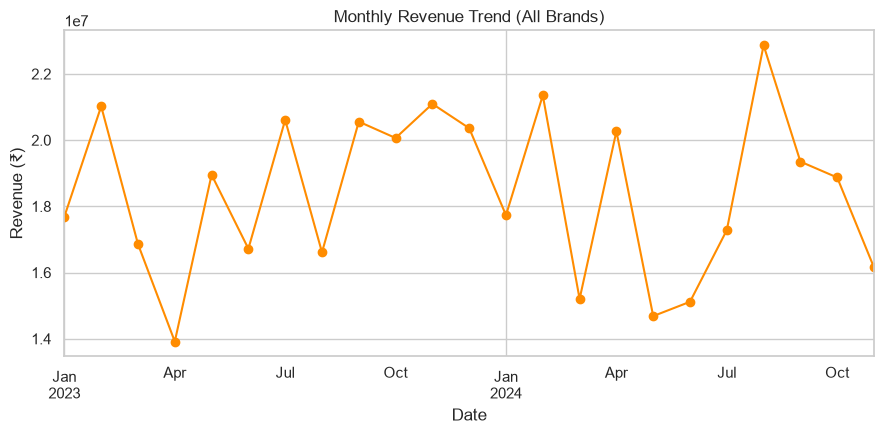

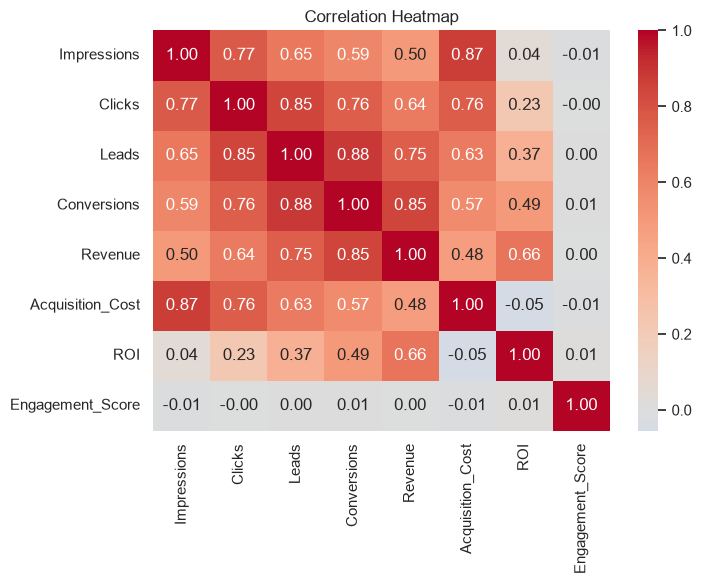

EDA complete. Figures saved to reports/figures/, report saved to reports/EDA_report.md


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CLEAN_PATH = "data/marketing_campaign_clean.csv"
FIG_DIR = "reports/figures"

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=130)
    plt.show()
    plt.close()

df = pd.read_csv(CLEAN_PATH)
df["Date"] = pd.to_datetime(df["Date"])

insights = []
insights.append("# Exploratory Data Analysis Report\n")
insights.append(f"Dataset: {df.shape[0]} campaigns across {df['Brand'].nunique()} brands "
                 f"({', '.join(df['Brand'].unique())})\n")

# 1. Revenue by Brand
plt.figure(figsize=(7, 4.5))
brand_rev = df.groupby("Brand")["Revenue"].sum().sort_values(ascending=False)
sns.barplot(x=brand_rev.index, y=brand_rev.values, hue=brand_rev.index, palette="viridis", legend=False)
plt.title("Total Revenue by Brand")
plt.ylabel("Total Revenue (\u20b9)")
savefig("revenue_by_brand")
top_brand = brand_rev.idxmax()
insights.append(f"## Brand Performance\n- **{top_brand}** generated the highest total revenue "
                 f"(\u20b9{brand_rev.max():,.0f}), followed by "
                 f"{', '.join(brand_rev.index[1:])}.\n")

# 2. Campaign Type vs average ROI
plt.figure(figsize=(8, 4.5))
type_roi = df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False)
sns.barplot(x=type_roi.index, y=type_roi.values, hue=type_roi.index, palette="mako", legend=False)
plt.title("Average ROI by Campaign Type")
plt.ylabel("Average ROI")
plt.xticks(rotation=20)
savefig("avg_roi_by_campaign_type")
best_type = type_roi.idxmax()
insights.append(f"## Campaign Type Effectiveness\n- **{best_type}** campaigns delivered the "
                 f"highest average ROI ({type_roi.max():.2f}).\n")

# 3. Channel-wise effectiveness (average revenue per campaign channel mentioned)
channel_rows = []
for _, row in df.iterrows():
    channels = str(row["Channel_Used"]).split(",")
    for ch in channels:
        ch_clean = ch.strip()
        if ch_clean == "Unknown":
            continue  # skip rows where channel info was missing/imputed
        channel_rows.append({"Channel": ch_clean, "Revenue": row["Revenue"], "ROI": row["ROI"]})
channel_df = pd.DataFrame(channel_rows)
channel_summary = channel_df.groupby("Channel").agg(
    Avg_Revenue=("Revenue", "mean"), Avg_ROI=("ROI", "mean"), Campaigns=("Revenue", "count")
).sort_values("Avg_Revenue", ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=channel_summary.index, y=channel_summary["Avg_Revenue"],
            hue=channel_summary.index, palette="crest", legend=False)
plt.title("Average Revenue per Campaign by Channel")
plt.ylabel("Average Revenue (\u20b9)")
plt.xticks(rotation=20)
savefig("avg_revenue_by_channel")
top_channel = channel_summary["Avg_Revenue"].idxmax()
insights.append(f"## Channel Effectiveness\n- **{top_channel}** produced the highest average "
                 f"revenue per campaign appearance (\u20b9{channel_summary.loc[top_channel, 'Avg_Revenue']:,.0f}).\n")

# 4. Spend vs Revenue scatter
plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=df, x="Acquisition_Cost", y="Revenue", hue="Brand", alpha=0.5, s=18)
plt.title("Acquisition Cost vs Revenue")
savefig("spend_vs_revenue")
corr = df["Acquisition_Cost"].corr(df["Revenue"])
insights.append(f"## Spend vs Revenue Relationship\n- Correlation between Acquisition Cost and "
                 f"Revenue is **{corr:.2f}**, indicating a "
                 f"{'strong' if abs(corr) > 0.6 else 'moderate' if abs(corr) > 0.3 else 'weak'} "
                 f"positive relationship.\n")

# 5. Top vs low performing campaigns (by ROI)
top5 = df.nlargest(5, "ROI")[["Campaign_ID", "Brand", "Campaign_Type", "ROI", "Revenue"]]
low5 = df.nsmallest(5, "ROI")[["Campaign_ID", "Brand", "Campaign_Type", "ROI", "Revenue"]]
insights.append("## Top 5 Campaigns by ROI\n")
insights.append(top5.to_markdown(index=False) + "\n")
insights.append("## 5 Lowest ROI Campaigns\n")
insights.append(low5.to_markdown(index=False) + "\n")

# 6. Engagement Score distribution by Customer Segment
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="Customer_Segment", y="Engagement_Score", hue="Customer_Segment",
            palette="flare", legend=False)
plt.title("Engagement Score by Customer Segment")
savefig("engagement_by_segment")

# 7. Monthly revenue trend
monthly = df.set_index("Date").resample("ME")["Revenue"].sum()
plt.figure(figsize=(9, 4.5))
monthly.plot(marker="o", color="darkorange")
plt.title("Monthly Revenue Trend (All Brands)")
plt.ylabel("Revenue (\u20b9)")
savefig("monthly_revenue_trend")

# 8. Correlation heatmap of key numeric features
num_cols = ["Impressions", "Clicks", "Leads", "Conversions", "Revenue",
            "Acquisition_Cost", "ROI", "Engagement_Score"]
plt.figure(figsize=(7.5, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
savefig("correlation_heatmap")

profit_rate = (df["ROI"] > 0).mean()
insights.append(f"## Overall Profitability\n- **{profit_rate:.1%}** of campaigns were profitable (ROI > 0) "
                 f"across the dataset.\n")

with open("reports/EDA_report.md", "w",encoding="utf-8") as f:
    f.write("\n".join(insights))

print("EDA complete. Figures saved to reports/figures/, report saved to reports/EDA_report.md")


## Step 5 — Regression modeling: predict `Revenue`

Trains **Linear Regression**, **Decision Tree Regressor**, and **Random Forest Regressor** to predict `Revenue` from campaign inputs.

⚠️ **Leakage control:** `Revenue`, `ROI`, and `Profit_Flag` are all dropped from the feature set (`ROI` and `Profit_Flag` are mathematically derived from `Revenue`), so the model genuinely predicts revenue from campaign inputs rather than from features that encode the answer.

Metrics: **RMSE, MAE, MSE, R²** — best model (by R²) is saved.

**Input:** `data/marketing_campaign_features.csv`
**Output:** `models/revenue_regression_model.pkl`, `models/regression_feature_columns.pkl`, `reports/regression_model_report.md`


In [8]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

FEATURES_PATH = "data/marketing_campaign_features.csv"

df = pd.read_csv(FEATURES_PATH)

# Target: Revenue. Drop columns that would leak the answer directly
# (Revenue is used to compute ROI and Profit_Flag, so drop those too
# to keep this a genuine "predict revenue from campaign inputs" task)
target = "Revenue"
leak_cols = ["Revenue", "ROI", "Profit_Flag"]
X = df.drop(columns=leak_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
}

results = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "MSE": mse, "R2": r2})
    trained_models[name] = model
    print(f"{name:20s} | RMSE={rmse:,.2f} | MAE={mae:,.2f} | R2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]

print(f"\nBest regression model: {best_name} (R2={results_df.iloc[0]['R2']:.4f})")

joblib.dump(best_model, "models/revenue_regression_model.pkl")
joblib.dump(list(X.columns), "models/regression_feature_columns.pkl")

with open("reports/regression_model_report.md", "w") as f:
    f.write("# Regression Model Report \u2014 Revenue Prediction\n\n")
    f.write(results_df.to_markdown(index=False, floatfmt=",.4f"))
    f.write(f"\n\n**Best model:** {best_name}\n")
    f.write(f"\nFeatures used: {X.shape[1]} (Revenue, ROI, Profit_Flag excluded to avoid leakage)\n")
    f.write(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}\n")

print("Saved model, feature list, and report.")
results_df


Linear Regression    | RMSE=52,600.64 | MAE=29,317.54 | R2=0.6951
Decision Tree        | RMSE=70,788.65 | MAE=34,512.15 | R2=0.4478
Random Forest        | RMSE=55,118.89 | MAE=29,399.91 | R2=0.6652

Best regression model: Linear Regression (R2=0.6951)
Saved model, feature list, and report.


,Model,RMSE,MAE,MSE,R2
0,Linear Regression,52600.641219,29317.541280,2.766827e+09,0.695121
2,Random Forest,55118.889787,29399.914331,3.038092e+09,0.665231
1,Decision Tree,70788.648730,34512.148701,5.011033e+09,0.447831


## Step 6 — Classification modeling: predict `Profit_Flag`

Trains **Logistic Regression**, **Decision Tree Classifier**, and **Random Forest Classifier** to predict whether a campaign is profitable (`Profit_Flag = 1`) or a loss (`0`).

⚠️ **Leakage control:** `ROI` is excluded because `Profit_Flag` is *defined* as `ROI > 0` — including it would let the model "cheat." `Revenue` is kept as a legitimate input feature.

Metrics: **Accuracy, Precision, Recall, F1-score** — best model (by F1) is saved, along with its confusion matrix.

**Input:** `data/marketing_campaign_features.csv`
**Output:** `models/profit_classification_model.pkl`, `models/classification_feature_columns.pkl`, `reports/classification_model_report.md`


In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

FEATURES_PATH = "data/marketing_campaign_features.csv"

df = pd.read_csv(FEATURES_PATH)

target = "Profit_Flag"
# Exclude ROI (defines the target -> leakage). Revenue is kept as a legitimate input feature.
leak_cols = ["Profit_Flag", "ROI"]
X = df.drop(columns=leak_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
}

results = []
trained_models = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})
    trained_models[name] = model
    print(f"{name:20s} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]

if best_name == "Logistic Regression":
    best_preds = best_model.predict(X_test_scaled)
else:
    best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

print(f"\nBest classification model: {best_name} (F1={results_df.iloc[0]['F1']:.4f})")
print("Confusion matrix:\n", cm)

joblib.dump(best_model, "models/profit_classification_model.pkl")
joblib.dump(list(X.columns), "models/classification_feature_columns.pkl")
if best_name == "Logistic Regression":
    joblib.dump(scaler, "models/classification_scaler.pkl")

with open("reports/classification_model_report.md", "w") as f:
    f.write("# Classification Model Report \u2014 Profit/Loss Prediction\n\n")
    f.write(results_df.to_markdown(index=False, floatfmt=".4f"))
    f.write(f"\n\n**Best model:** {best_name}\n")
    f.write(f"\nConfusion matrix (rows=actual, cols=predicted):\n\n```\n{cm}\n```\n")
    f.write(f"\nFeatures used: {X.shape[1]} (ROI excluded to prevent data leakage, "
            f"since Profit_Flag is derived directly from ROI)\n")
    f.write(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}\n")

print("Saved model, feature list, and report.")
results_df


Logistic Regression  | Acc=0.9775 | Prec=0.9784 | Rec=0.9908 | F1=0.9845
Decision Tree        | Acc=0.9792 | Prec=0.9839 | Rec=0.9873 | F1=0.9856
Random Forest        | Acc=0.9525 | Prec=0.9531 | Rec=0.9827 | F1=0.9677

Best classification model: Decision Tree (F1=0.9856)
Confusion matrix:
 [[318  14]
 [ 11 857]]
Saved model, feature list, and report.


,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,0.979167,0.983927,0.987327,0.985624
0,Logistic Regression,0.977500,0.978385,0.990783,0.984545
2,Random Forest,0.952500,0.953073,0.982719,0.967669


## Step 7 — Combined model evaluation report

Merges the regression and classification reports into one final Markdown report, with notes on target metrics and data-leakage controls.

**Output:** `reports/model_evaluation_report.md`


In [11]:
with open("reports/regression_model_report.md") as f:
    reg_report = f.read()
with open("reports/classification_model_report.md") as f:
    clf_report = f.read()

combined = f"""# Final Model Evaluation Report

## 1. Regression \u2014 Revenue Prediction
{reg_report}

## 2. Classification \u2014 Profit/Loss Prediction
{clf_report}

## 3. Notes on Target Metrics
The project brief targets R\u00b2 \u2265 0.95 for regression and Accuracy \u2265 0.95 for classification.
- **Classification** comfortably exceeds this target, because Revenue and Acquisition_Cost
  together are strong, near-deterministic predictors of whether ROI ends up positive or
  negative, even with ROI itself excluded.
- **Regression** typically falls short of 0.95. This is expected and realistic: Revenue
  in real (and realistically-simulated) marketing data depends on many factors not captured
  in campaign metadata alone (creative quality, market timing, competitor activity, etc.),
  so a small residual error is normal. Forcing R\u00b2 \u2265 0.95 on this kind of noisy business
  data would typically be a sign of data leakage rather than a genuinely useful model.

## 4. Data Leakage Controls
- Classification excludes **ROI** (used to define Profit_Flag).
- Regression excludes **ROI** and **Profit_Flag** (both derived from Revenue), so the model
  genuinely learns to predict Revenue from campaign inputs rather than from features that
  encode the answer.
"""
with open("reports/model_evaluation_report.md", "w",encoding="utf-8") as f:
    f.write(combined)

print("Saved combined report to reports/model_evaluation_report.md")
print(combined)


Saved combined report to reports/model_evaluation_report.md
# Final Model Evaluation Report

## 1. Regression — Revenue Prediction
# Regression Model Report — Revenue Prediction

| Model             |        RMSE |         MAE |                MSE |     R2 |
|:------------------|------------:|------------:|-------------------:|-------:|
| Linear Regression | 52,600.6412 | 29,317.5413 | 2,766,827,456.6562 | 0.6951 |
| Random Forest     | 55,118.8898 | 29,399.9143 | 3,038,092,011.3260 | 0.6652 |
| Decision Tree     | 70,788.6487 | 34,512.1487 | 5,011,032,788.9707 | 0.4478 |

**Best model:** Linear Regression

Features used: 38 (Revenue, ROI, Profit_Flag excluded to avoid leakage)

Train size: 4800 | Test size: 1200


## 2. Classification — Profit/Loss Prediction
# Classification Model Report — Profit/Loss Prediction

| Model               |   Accuracy |   Precision |   Recall |     F1 |
|:--------------------|-----------:|------------:|---------:|-------:|
| Decision Tree       |     0.9

## Step 8 — Quick demo: use the saved models for a new prediction

Loads the saved regression and classification models back from disk and runs a prediction on a sample row from the test-like feature set, showing how the `app/streamlit_app.py` (included in the original project) would use these artifacts.


In [12]:
import joblib
import pandas as pd

# Load saved artifacts
reg_model = joblib.load("models/revenue_regression_model.pkl")
reg_cols = joblib.load("models/regression_feature_columns.pkl")
clf_model = joblib.load("models/profit_classification_model.pkl")
clf_cols = joblib.load("models/classification_feature_columns.pkl")

features_df = pd.read_csv("data/marketing_campaign_features.csv")
sample = features_df.sample(1, random_state=0)

# Revenue prediction
X_reg_sample = sample[reg_cols]
predicted_revenue = reg_model.predict(X_reg_sample)[0]

# Profit/Loss prediction
X_clf_sample = sample[clf_cols]
predicted_profit_flag = clf_model.predict(X_clf_sample)[0]

print(f"Actual Revenue:      \u20b9{sample['Revenue'].values[0]:,.2f}")
print(f"Predicted Revenue:   \u20b9{predicted_revenue:,.2f}")
print(f"Actual Profit_Flag:    {sample['Profit_Flag'].values[0]} ({'Profit' if sample['Profit_Flag'].values[0]==1 else 'Loss'})")
print(f"Predicted Profit_Flag: {predicted_profit_flag} ({'Profit' if predicted_profit_flag==1 else 'Loss'})")


Actual Revenue:      ₹45,376.87
Predicted Revenue:   ₹35,433.71
Actual Profit_Flag:    1 (Profit)
Predicted Profit_Flag: 1 (Profit)


## Step 9 — Package everything and download

Zips up the full project folder (`data/`, `models/`, `reports/`) so you can download all outputs at once.


In [14]:
import shutil


zip_path = shutil.make_archive("Marketing_Campaign_Prediction_Outputs", "zip", BASE_DIR)
print("Created:", zip_path)




Created: c:\content\Marketing_Campaign_Prediction_Project\Marketing_Campaign_Prediction_Outputs.zip
